In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc

In [2]:
conn = pyodbc.connect(
   r"DRIVER={ODBC Driver 17 for SQL Server};"
    r"SERVER=DESKTOP-L4LHVC6\MSSQL;"
    r"DATABASE=customer_churn;"
    r"Trusted_Connection=yes;"
)

print("Connection Successfully")

Connection Successfully


In [3]:
plt.style.use('seaborn-v0_8-whitegrid')

In [4]:
df= pd.read_csv(r"D:\masters in analyst\Telco_Customer_Churn_Analysis\Telco-Customer-Churn.csv")

In [5]:
print('Shape: ', df.shape)

Shape:  (7043, 21)


In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
check_rows = df[pd.to_numeric(df['TotalCharges'],errors='coerce').isna()]

In [9]:
check_rows[['customerID','tenure','MonthlyCharges', 'TotalCharges']]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


* finding: These 11 rows have blank string for Total charges and every single one has tenure = 0.
* That makes sense: these are brand-new customers who haven't been billed yet, so there's no total to report.
* so, i set TotalCharegs to 0 for these rows, and then convert whole column to numeric.

In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [12]:
#chur_flag new column
df['Churn_Flag'] = (df['Churn'] == 'Yes').astype(int)

In [13]:
print(df['TotalCharges'].isna().sum(), 'nulls remaining')
print(df.dtypes[['TotalCharges', 'Churn_Flag']])

0 nulls remaining
TotalCharges    float64
Churn_Flag        int32
dtype: object


In [14]:
# Quick duplicate check on primary key
print('Duplicate customerIDs:', df['customerID'].duplicated().sum())

Duplicate customerIDs: 0


In [15]:
df.to_csv(r'D:\masters in analyst\Telco_Customer_Churn_Analysis\Telco-Customer-Churn_clean.csv', index = False)
print('Saved cleaned file.')

Saved cleaned file.


* EDA

Overall churn rate: 26.5%


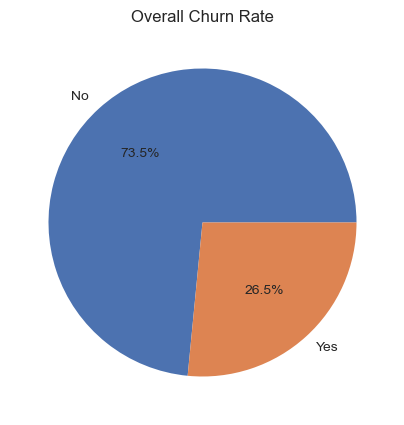

In [17]:
# pie chart

churn_rate = df['Churn_Flag'].mean()
print(f'Overall churn rate: {churn_rate:.1%}')

#The f'...' is a "fill-in-the-blank" string — whatever is inside { } gets swapped in.
#{churn_rate:.1%} = take our number (like 0.265) and display it as a percentage with 1 decimal (26.5%).

fig, ax = plt.subplots(figsize=(5,5))
df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax, colors=['#4C72B0','#DD8452'])
ax.set_ylabel('')
ax.set_title('Overall Churn Rate')
plt.show()

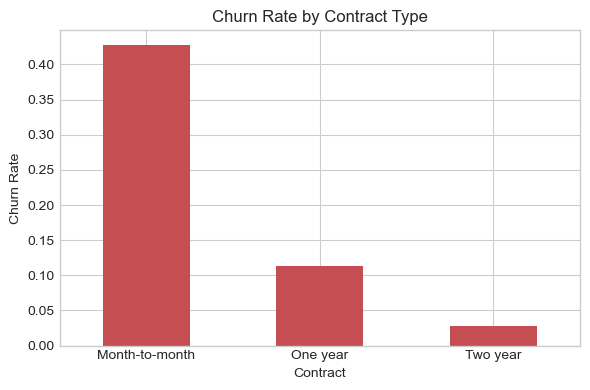

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn_Flag, dtype: float64

In [18]:
#Does contract type affect churn?
#The bar chart

contract_churn = df.groupby('Contract')['Churn_Flag'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6,4))
contract_churn.plot(kind='bar', ax=ax, color='#C44E52')
ax.set_ylabel('Churn Rate')
ax.set_title('Churn Rate by Contract Type')
ax.set_xticklabels(contract_churn.index, rotation=0)
plt.tight_layout()
plt.show()

contract_churn

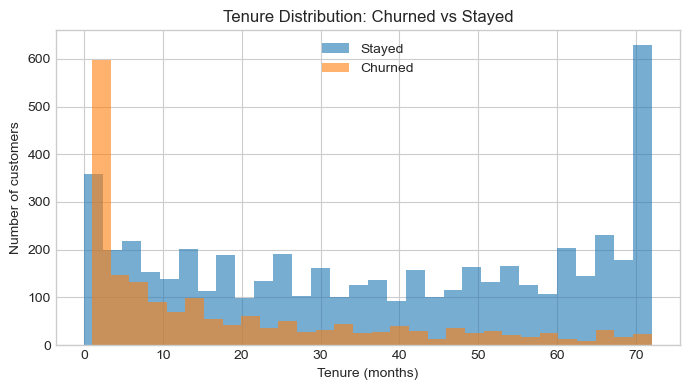

In [19]:
#Does tenure matter? 
#New customers are usually the highest churn risk.
#The histogram

fig, ax = plt.subplots(figsize=(7,4))
ax.hist(df[df['Churn']=='No']['tenure'], bins=30, alpha=0.6, label='Stayed')
ax.hist(df[df['Churn']=='Yes']['tenure'], bins=30, alpha=0.6, label='Churned')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Number of customers')
ax.set_title('Tenure Distribution: Churned vs Stayed')
ax.legend()
plt.tight_layout()
plt.show()

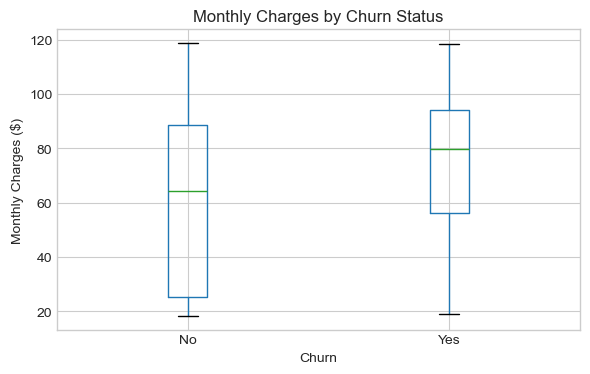

In [20]:
#Does monthly charge relate to churn?
#The box plot

fig, ax = plt.subplots(figsize=(6,4))
df.boxplot(column='MonthlyCharges', by='Churn', ax=ax)
ax.set_title('Monthly Charges by Churn Status')
ax.set_ylabel('Monthly Charges ($)')
plt.suptitle('')
plt.tight_layout()
plt.show()

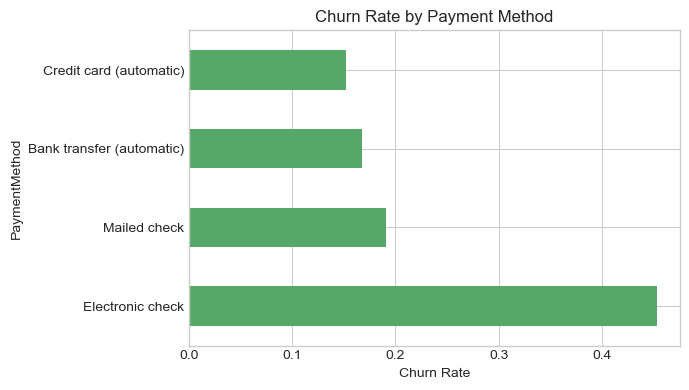

PaymentMethod
Electronic check             0.452854
Mailed check                 0.191067
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Name: Churn_Flag, dtype: float64

In [21]:
#Which payment methods have the highest churn?
#The horizontal bar chart

payment_churn = df.groupby('PaymentMethod')['Churn_Flag'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7,4))
payment_churn.plot(kind='barh', ax=ax, color='#55A868')
ax.set_xlabel('Churn Rate')
ax.set_title('Churn Rate by Payment Method')
plt.tight_layout()
plt.show()

payment_churn